[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Train shape: (7613, 5)
Test shape: (3263, 4)
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


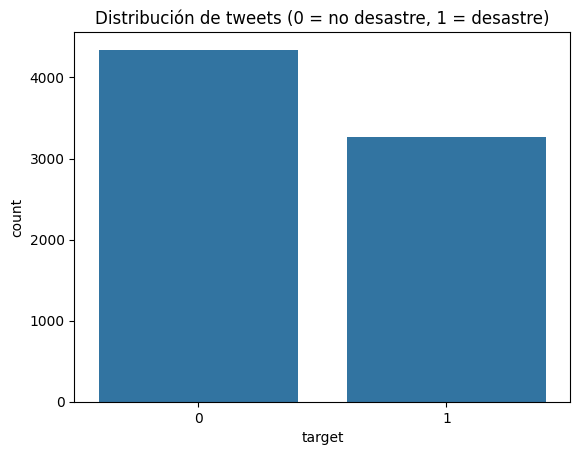

In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from collections import Counter
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from scipy.sparse import hstack, csr_matrix

nltk.download('stopwords')
nltk.download('vader_lexicon')

stop_words = set(stopwords.words('english'))
sia = SentimentIntensityAnalyzer()
vader_lexicon = sia.lexicon

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

train.head()

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print(train.isnull().sum())

sns.countplot(x="target", data=train)
plt.title("Distribución de tweets (0 = no desastre, 1 = desastre)")
plt.show()

## Procesamiento de datos

---
Para limpiar los tweets se transformara el texto pasandolo todo a minúsculas, eliminando URLs, menciones a @usuarios o #hashtags y algunos caracteres especiales

In [6]:
def limpiar_texto_basico(text):
    """Versión para modelos: solo letras y espacios, stopwords removidas."""
    if pd.isna(text): return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    return " ".join(tokens)

EMOTICON_RE = r"[:;=X][-oO\-]?[pPD\)\]\(\]/\\S]+"
EMOJI_RE = r'[\U0001F600-\U0001F64F]'

# como arriba pero revisando si hay emoticonos
def limpiar_texto_preservando_emoticons(text):
    """Versión para sentimiento: preserva emoticons y emojis, reduce URLs/mention"""
    if pd.isna(text): return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    tokens = text.split()
    clean_tokens = []
    for t in tokens:
        if re.search(EMOTICON_RE, t):
            clean_tokens.append(t)
            continue
        if re.search(r'[\U00010000-\U0010ffff]', t):
            clean_tokens.append(t)
            continue
        t2 = re.sub(r"[^a-zA-Z]", "", t)
        if t2 and t2 not in stop_words:
            clean_tokens.append(t2)
    return " ".join(clean_tokens)

train["clean_text"] = train["text"].apply(limpiar_texto_basico)
train["clean_text_sent"] = train["text"].apply(limpiar_texto_preservando_emoticons)

# Print para ver si funciona
display(train[["text","clean_text","clean_text_sent"]].head(15))

,text,clean_text,clean_text_sent
0,Our Deeds are the Reason of this #earthquake M...,deeds reason earthquake may allah forgive us,deeds reason earthquake may allah forgive us
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,residents asked shelter place notified officer...,residents asked shelter place notified officer...
3,"13,000 people receive #wildfires evacuation or...",people receive wildfires evacuation orders cal...,people receive wildfires evacuation orders cal...
4,Just got sent this photo from Ruby #Alaska as ...,got sent photo ruby alaska smoke wildfires pou...,got sent photo ruby alaska smoke wildfires pou...
5,#RockyFire Update => California Hwy. 20 closed...,rockyfire update california hwy closed directi...,rockyfire update california hwy closed directi...
6,#flood #disaster Heavy rain causes flash flood...,flood disaster heavy rain causes flash floodin...,flood disaster heavy rain causes flash floodin...
7,I'm on top of the hill and I can see a fire in...,top hill see fire woods,im top hill see fire woods
8,There's an emergency evacuation happening now ...,emergency evacuation happening building across...,theres emergency evacuation happening building...
9,I'm afraid that the tornado is coming to our a...,afraid tornado coming area,im afraid tornado coming area


## Frecuencia de palabras

Palabras más comunes en tweets de desastre:
[('fire', 182), ('news', 148), ('amp', 135), ('disaster', 121), ('via', 121), ('california', 115), ('suicide', 112), ('police', 109), ('people', 105), ('killed', 95)]

Palabras más comunes en tweets NO desastre:
[('like', 254), ('amp', 209), ('new', 171), ('get', 163), ('one', 133), ('body', 116), ('would', 101), ('via', 99), ('video', 96), ('people', 94)]


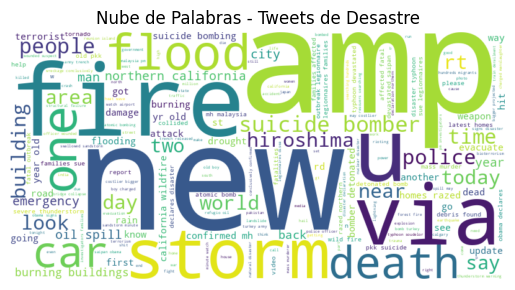

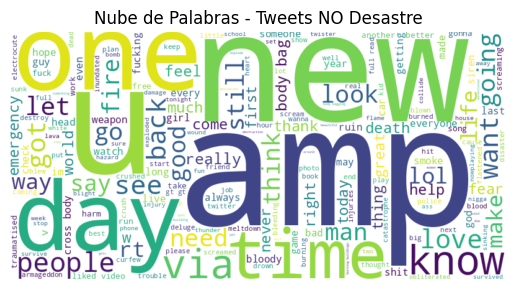

In [7]:
def obtener_frecuencia(textos):
    all_words = " ".join(textos).split()
    return Counter(all_words)

freq_disaster = obtener_frecuencia(train[train["target"]==1]["clean_text"])
freq_nondisaster = obtener_frecuencia(train[train["target"]==0]["clean_text"])

print("Palabras más comunes en tweets de desastre:")
print(freq_disaster.most_common(10))

print("\nPalabras más comunes en tweets NO desastre:")
print(freq_nondisaster.most_common(10))

# Nube de palabras para desastres
wc_disaster = WordCloud(width=800, height=400, background_color="white").generate(" ".join(train[train["target"]==1]["clean_text"]))
plt.imshow(wc_disaster, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de Palabras - Tweets de Desastre")
plt.show()

# Nube de palabras para no desastres
wc_nondisaster = WordCloud(width=800, height=400, background_color="white").generate(" ".join(train[train["target"]==0]["clean_text"]))
plt.imshow(wc_nondisaster, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de Palabras - Tweets NO Desastre")
plt.show()


## Histogramas

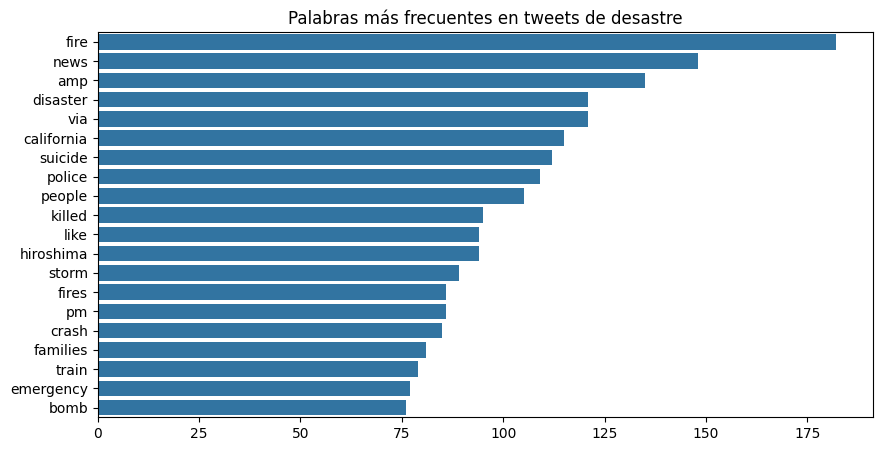

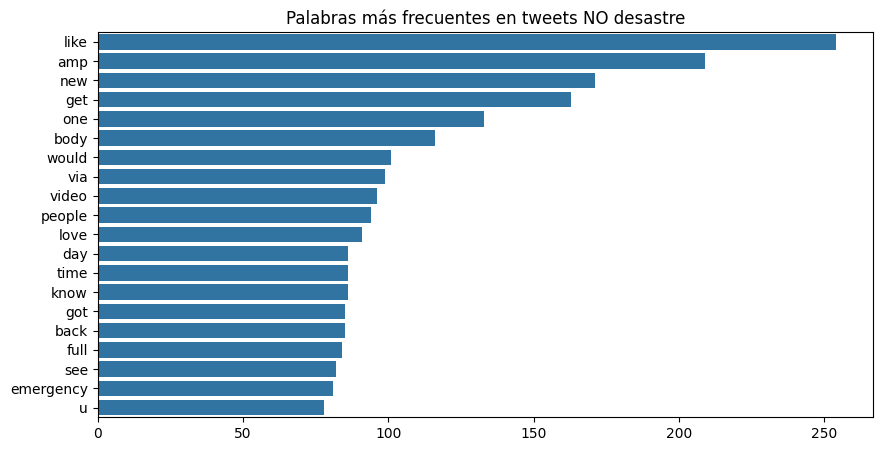

In [8]:
def plot_top_words(freq, title):
    words, counts = zip(*freq.most_common(20))
    plt.figure(figsize=(10,5))
    sns.barplot(x=list(counts), y=list(words))
    plt.title(title)
    plt.show()

plot_top_words(freq_disaster, "Palabras más frecuentes en tweets de desastre")
plot_top_words(freq_nondisaster, "Palabras más frecuentes en tweets NO desastre")


## Preparar vectores para la clasificacion


===== Naive Bayes =====
              precision    recall  f1-score   support

           0       0.79      0.92      0.85       869
           1       0.86      0.68      0.76       654

    accuracy                           0.82      1523
   macro avg       0.83      0.80      0.81      1523
weighted avg       0.82      0.82      0.81      1523


===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.81      0.91      0.86       869
           1       0.85      0.72      0.78       654

    accuracy                           0.83      1523
   macro avg       0.83      0.81      0.82      1523
weighted avg       0.83      0.83      0.82      1523


===== Random Forest =====
              precision    recall  f1-score   support

           0       0.79      0.87      0.83       869
           1       0.80      0.69      0.74       654

    accuracy                           0.79      1523
   macro avg       0.79      0.78      0.78

,accuracy,f1,precision,recall
Logistic Regression,0.825345,0.779070,0.852727,0.717125
LinearSVC,0.802364,0.765394,0.780604,0.750765
Naive Bayes,0.818122,0.763450,0.864603,0.683486
Random Forest,0.790545,0.738310,0.796460,0.688073


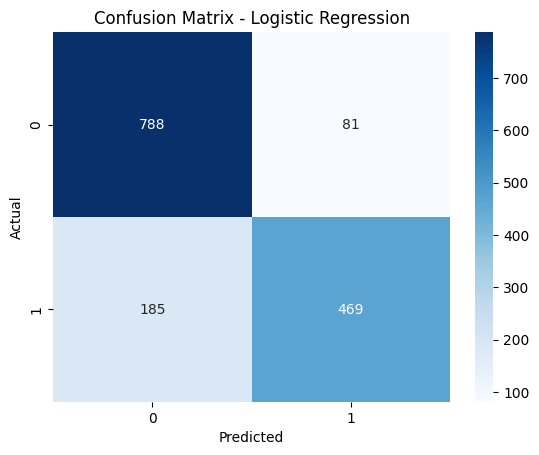

In [9]:
X = train["clean_text"]
y = train["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

vectorizer = TfidfVectorizer(ngram_range=(1,2), stop_words="english", max_features=10000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# --- MODELOS base (los que ya tenías) + SVM como alternativa fuerte en texto ---
modelos = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, solver="liblinear"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "LinearSVC": LinearSVC(max_iter=10000)
}

resultados = {}
metricas = {}

for name, model in modelos.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    resultados[name] = (model, y_pred)
    metricas[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred)
    }
    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred))

#  tabla de métricas
df_metricas = pd.DataFrame(metricas).T
display(df_metricas.sort_values("f1", ascending=False))

# matriz de confusion para Logistic Regression
sns.heatmap(confusion_matrix(y_test, resultados["Logistic Regression"][1]), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression"); plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.show()


In [ ]:
# Ahora agarramos el que nos tiro mejores resultados arriba y lo ponemos en "best_model" y este nos
# ayudara a clasificar el tweet
best_model = resultados["Logistic Regression"][0]

def clasificar_tweet(text, model=best_model, vectorizer=vectorizer, include_negativity=False):

    cleaned = limpiar_texto_basico(text)
    cleaned_sent = limpiar_texto_preservando_emoticons(text)
    # vectorizar
    x_vec = vectorizer.transform([cleaned])
    if include_negativity:
        neg_feat = calcular_negativity_numeric(cleaned_sent)
        x_vec = hstack([x_vec, csr_matrix(np.array([[neg_feat]]))])
    try:
        pred = model.predict(x_vec)[0]
    except Exception as e:
        pred = None
    proba = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(x_vec)[0].tolist()
    vader_scores = sia.polarity_scores(cleaned_sent)
    counts = contar_palabras_pos_neg_neu(cleaned_sent)
    return {
        "pred_label": int(pred),
        "pred_proba": proba,
        "cleaned": cleaned,
        "vader": vader_scores,
        "word_counts": counts
    }

print(clasificar_tweet("There is a fire in downtown!!! Many people injured :( #help"))
